# Обучение классификатор текстов с помощью RNN

In [64]:
!pip install datasets

In [65]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import datasets

import numpy as np
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from datasets import load_dataset
from nltk.tokenize import word_tokenize
from sklearn.model_selection import train_test_split
import nltk

from collections import Counter
from typing import List
import string

import seaborn
seaborn.set(palette='summer')

In [66]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [67]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

### Подготовка данных

In [68]:
dataset = datasets.load_dataset('imdb')

In [69]:
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

In [70]:
counter = Counter()

for example in dataset['train']['text']:
  # приводим к нижнему регистру и убираем пунктуацию
  processed_text = example.lower().translate(str.maketrans('', '', string.punctuation))

  for word in word_tokenize(processed_text):
    counter[word] += 1

# str.maketrans('', '', string.punctuation) создаёт словарь, ASCII код пунктуации : None
# translate применяет таблицу

In [71]:
vocab = set(['<unk>', '<bos>', '<eos>', '<pad>'])
counter_threshold = 25

for char, cnt in counter.items():
  if cnt > counter_threshold:
    vocab.add(char)

In [72]:
len(vocab)

11399

In [73]:
vocab

{'resurrected',
 'ceremony',
 '11th',
 'bon',
 'apart',
 'script',
 'million',
 'townspeople',
 'tomlinson',
 '2008',
 'audiencebr',
 'wry',
 'humor',
 'greatest',
 'extremes',
 'shocked',
 'luise',
 'oldest',
 'overseas',
 'pam',
 'voices',
 'recurring',
 'piano',
 'molly',
 'lamas',
 'imo',
 'dani',
 'classmates',
 'deborah',
 'overcome',
 'went',
 'glimpse',
 'helpless',
 'marks',
 'enormously',
 'courtesy',
 'hale',
 'christ',
 'radar',
 'translation',
 'recommending',
 'indiana',
 'dominates',
 'conversations',
 'bart',
 'attracts',
 'exploit',
 'diana',
 'boring',
 'spice',
 'failures',
 'chong',
 'crisis',
 'polly',
 'envy',
 'sunk',
 'cheadle',
 'alfred',
 'fx',
 'holm',
 'goofs',
 'benoit',
 'avoiding',
 'hobgoblins',
 '1967',
 'patriotic',
 'estate',
 'refuses',
 'superficial',
 'enlightened',
 'maclean',
 'depardieu',
 'artistry',
 'attributed',
 'contrasting',
 'originalbr',
 'flashes',
 'guardian',
 'lampoons',
 'ewoks',
 'di',
 'love',
 'nasa',
 '100',
 'uniquely',
 'scht

Заведём 2 словаря вроде маппинга из слов в индексы и наоборот

In [74]:
word2ind = {char: i for i, char in enumerate(vocab)}
ind2word = {i: char for char, i in word2ind.items()}

### Создаём датасет

Для того, чтобы работать с torch.utils.data.DataLoader датасет должен иметь: init, getitem, len

In [78]:
class WordDataset:
  def __init__(self, sentences):
    self.data = sentences
    self.unk_id = word2ind['<unk>']
    self.bos_id = word2ind['<bos>']
    self.eos_id = word2ind['<eos>']
    self.pad_id = word2ind['<pad>']

  def __getitem__(self, idx):
    processed_text = self.data[idx]['text'].lower().translate(str.maketrans('', '', string.punctuation))
    tokenized_sentence = [self.bos_id]
    tokenized_sentence += [word2ind.get(word, self.unk_id) for word in word_tokenize(processed_text)]
    tokenized_sentence += [self.eos_id]

    train_sample = {
        "text": tokenized_sentence,
        "label": self.data[idx]['label']
    }

    return train_sample

  def __len__(self):
    return len(self.data)

In [85]:
# функция для обьединения последовательностей разного размера в батч
def collate_fn_with_padding(input_batch, pad_id=word2ind['<pad>'], max_len=256):
  seq_lens = [len(x['text']) for x in input_batch]
  max_seq_len = min(max(seq_lens), max_len)

  new_batch = []
  for sequence in input_batch:
    sequence['text'] = sequence['text'][:max_seq_len]
    for i in range(max_seq_len - len(sequence['text'])):
      sequence['text'].append(pad_id)

    new_batch.append(sequence['text'])

  sequences = torch.LongTensor(new_batch).to(device)
  labels = torch.LongTensor([x['label'] for x in input_batch]).to(device)

  new_batch = {
      'input_ids': sequences,
      'label': labels
  }
  return new_batch

In [89]:
train_dataset = WordDataset(dataset['train'])

np.random.seed(42)
idx = np.random.choice(np.arange(len(dataset['train'])), 2000)
eval_dataset = WordDataset(dataset['test'].select(idx))

batch_size = 128
train_dataloader = DataLoader(train_dataset, shuffle=True, collate_fn=collate_fn_with_padding, batch_size=batch_size)

eval_dataloader = DataLoader(eval_dataset, shuffle=False, collate_fn=collate_fn_with_padding, batch_size=batch_size)

### Архитектура модели

In [97]:
len(vocab)

11399

In [102]:
class CharLM(nn.Module):
  def __init__(self, hidden_dim, vocab_size, num_classes=2, aggregation_type: str='max'):
    super(CharLM, self).__init__()
    self.embedding = torch.nn.Embedding(vocab_size, hidden_dim)
    self.rnn = nn.RNN(hidden_dim, hidden_dim, batch_first=True)
    self.linear = nn.Linear(hidden_dim, hidden_dim)
    self.projection = nn.Linear(hidden_dim, num_classes)

    self.non_lin = nn.Tanh()
    self.dropout = nn.Dropout(p=0.1)

    self.aggregation_type = aggregation_type


  def forward(self, input_batch):
    embeddings = self.embedding(input_batch) # [batch_size, seq_len, hidden_dim]
    output, _ = self.rnn(embeddings) # [batch_size, seq_len, hidden_dim]

    if self.aggregation_type == 'max': #[batch_size, hidden_dim]
      output = output.max(dim=1)[0]

    elif self.aggregation_type == 'mean': #[batch_size, hidden_dim]
      output = output.mean(dim=1)
    else:
      raise ValueError("Invalid aggregation_type")

    output = self.dropout(self.linear(self.non_lin(output)))
    prediction = self.projection(self.non_lin(output))
    return prediction

In [103]:
def evaluate(model):
  predictions = []
  target = []

  with torch.no_grad():
    for batch in eval_dataloader:
      logits = model(batch['input_ids'])
      predictions.append(logits.argmax(dim=1))
      target.append(batch['label'])

  predictions = torch.cat(predictions)
  target = torch.cat(target)
  accuracy = (predictions == target).float().mean().item()

  return accuracy

In [104]:
model = CharLM(hidden_dim=256, vocab_size=len(vocab)).to(device)
criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
optimizer = torch.optim.Adam(model.parameters())

In [108]:
num_epoch = 5
eval_steps = len(train_dataloader) / 2

losses_type = {}
accuracies_type = {}

for aggregation_type in ['max', 'mean']:
  losses = []
  accuracies = []

  model = CharLM(
        hidden_dim=256, vocab_size=len(vocab), aggregation_type=aggregation_type).to(device)
  criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
  optimizer = torch.optim.Adam(model.parameters())

  for epoch in range(num_epoch):
    epoch_losses = []
    model.train()
    for i, batch in enumerate(train_dataloader):
      optimizer.zero_grad()
      logits = model(batch['input_ids'])
      loss = criterion(logits, batch['label'])
      loss.backward()
      optimizer.step()

      epoch_losses.append(loss.item())
      if i % eval_steps == 0:
        model.eval()
        accuracies.append(evaluate(model))
        model.train()

    losses.append(sum(epoch_losses) / len(epoch_losses))

  losses_type[aggregation_type] = losses
  accuracies_type[aggregation_type] = accuracies

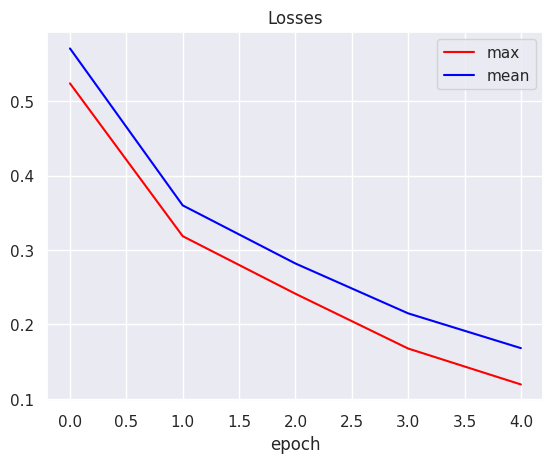

In [112]:
for (name, values), color in zip(losses_type.items(), ['red', 'blue']):
    plt.plot(np.arange(len(losses_type[name])), losses_type[name], color=color, label=name)

plt.title('Losses')
plt.xlabel("epoch")
plt.legend()
plt.show()

Exception ignored in: <function tqdm.__del__ at 0x79fd906d9ee0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/tqdm/std.py", line 1148, in __del__
    self.close()
  File "/usr/local/lib/python3.12/dist-packages/tqdm/notebook.py", line 280, in close
    self.disp(bar_style='success', check_delay=False)
    ^^^^^^^^^
AttributeError: 'tqdm' object has no attribute 'disp'


Лучшая accuracy для подхода max: 86.60
Лучшая accuracy для подхода mean: 85.95


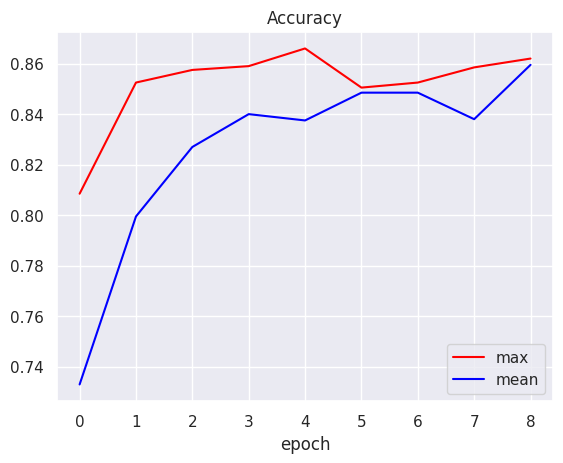

In [111]:
for (name, values), color in zip(losses_type.items(), ['red', 'blue']):
    plt.plot(np.arange(len(accuracies_type[name][1:])), accuracies_type[name][1:], color=color, label=name)
    print(f"Лучшая accuracy для подхода {name}: {(max(accuracies_type[name]) * 100):.2f}")

plt.title('Accuracy')
plt.xlabel("epoch")
plt.legend()
plt.show()